# Heavy Ion Minimum Bias Open Data: charged-particle suppression and tracking efficiency

In this notebook we work with ATLAS heavy ion minimum bias open data. We will:

- retrieve public files with `atlasopenmagic`,
- read `CollectionTree` with `uproot`,
- manipulate variable-length event data with `awkward`,
- study centrality and charged-particle spectra in data,
- calculate the central-to-peripheral ratio $R_{CP}$,
- and use MC truth information to study tracking efficiency.

We will introduce the relevant heavy ion concepts as we go. Let's get started!

## Setup
We will access the ATLAS Open Data directly from the notebook. To do this, we use the `atlasopenmagic` package, which will provide the the released datasets' file locations.

We first install and import the libraries needed for the analysis, then select the 2024 heavy ion minimum bias release.

In [ ]:
# Install the necessary libraries (not needed in myBinder)
import sys
import os.path

%pip install atlasopenmagic

from atlasopenmagic import install_from_environment
install_from_environment()


In [ ]:
# Import the libraries that we are going to use
import requests
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import atlasopenmagic as atom

from pathlib import Path

# Select the heavy ion minimum bias release.
atom.set_release("2024r-hi")

GeV = 1e3   # Momentum variables are stored in MeV
TeV = 1e6


To keep the first run simple, we start with a single data file. With `ENTRY_STOP = None`, all events in that file are processed. For a quicker test, you can set `ENTRY_STOP` to a smaller number of events.

In [2]:
ENTRY_STOP = None

# Part I — Data: centrality and $R_{CP}$

At lower temperatures, there is a hadron gas, where particles like pions, kaons, and eta mesons exist. As the temperature rises, we enter the **quark-gluon plasma (QGP)** state, where quarks and gluons are no longer confined within hadrons and can move freely. This state occurs above a critical temperature, and studying QGP helps us understand the early universe and strong interaction physics.

To study the QGP, heavy ion collisions are employed, where nuclei of heavy elements, such as lead, are accelerated to nearly the speed of light and collided. In the central region of the collision, a significant amount of energy is concentrated, and under extreme temperature and pressure conditions, QGP is formed. The geometry of these collisions is a critical factor in determining the experimental outcomes. **Centrality** serves as a measure of the overlap area between two colliding nuclei. Centrality percentages, such as 0-10% or 30-50%, indicate the degree of overlap, with 0-10% corresponding to highly central collisions, and 30-50% representing more peripheral collisions.

We will begin by looking at how centrality is represented in the open data and how charged-particle production changes across centrality intervals.

In [ ]:
# The heavy ion data are retrieved directly through `atlasopenmagic`.
# The heavy ion release was selected above with atom.set_release("2024r-hi").
urls_data = atom.get_urls("data", protocol="https", cache=True)

print(f"Number of data files: {len(urls_data)}")


In [ ]:
# For simplicity, we are only using the first file
data_filename = urls_data[0]
data_tree = uproot.open({data_filename: "CollectionTree"})

print(f"Entries in first data file: {data_tree.num_entries:,}")

The data file contains most of the quantities needed for this exercise:

**Event level**

- `EventInfoAuxDyn.FCalEtA`: Total transverse energy deposited in the A-side of the Forward Calorimeter
- `EventInfoAuxDyn.FCalEtC`: Total transverse energy deposited in the C-side of the Forward Calorimeter
- `EventInfoAuxDyn.CentralityMin`: The lower bound of the centrality class for the event
- `EventInfoAuxDyn.CentralityMax`: The upper bound of the centrality class for the event

**Inner Detector tracks**

- `InDetTrackParticlesAuxDyn.theta`: Track kinematics in perigee representation of parameters, defined wrt beamspot
- `InDetTrackParticlesAuxDyn.qOverP`: Track kinematics in perigee representation of parameters, defined wrt beamspot
- `InDetTrackParticlesAuxDyn.phi`: Track kinematics in perigee representation of parameters, defined wrt beamspot
- `InDetTrackParticlesAuxDyn.d0`: Transverse impact parameter, i.e. the distance of the closest point of the track to the beamspot on the transverse plane
- `InDetTrackParticlesAuxDyn.z0`: Longitudinal impact parameter, i.e. the track's distance from the beamspot along the z-axis, calculated at the point of closest approach to the beamspot on the transverse plane
- `InDetTrackParticlesAuxDyn.HITight`: Indicates if a track passes the tight track selection in the inner detector, with 1 for passing and 0 for failing


For these tracks, `pt` and `eta` are not explicitly included. We derive them from the defining track parameters:

$$
p_T = \frac{|\sin\theta|}{|q/p|},
\qquad
\eta = -\ln\tan\left(\frac{\theta}{2}\right).
$$

A full list of variables and their description can be found in the [documentation on analysis variables for ATLAS Open Data](https://atlas-physlite-content-opendata.web.cern.ch), under the heavy ion collisions tab.


In [5]:
# Retrieving the branches that will be used
DATA_BRANCHES = [
    "EventInfoAuxDyn.eventNumber",
    "EventInfoAuxDyn.FCalEtA",
    "EventInfoAuxDyn.FCalEtC",
    "EventInfoAuxDyn.CentralityMin",
    "EventInfoAuxDyn.CentralityMax",
    "InDetTrackParticlesAuxDyn.theta",
    "InDetTrackParticlesAuxDyn.qOverP",
    "InDetTrackParticlesAuxDyn.phi",
    "InDetTrackParticlesAuxDyn.d0",
    "InDetTrackParticlesAuxDyn.z0",
    "InDetTrackParticlesAuxDyn.HITight",
]

data_arrays = data_tree.arrays(DATA_BRANCHES, entry_stop=ENTRY_STOP)


We first derive the track $p_T$ and $\eta$, and then organize the track and event information into Awkward arrays. This makes the quantities easier to access when applying selections and producing plots later in the notebook.

In [ ]:
# Reconstructed tracks
theta = data_arrays["InDetTrackParticlesAuxDyn.theta"]
q_over_p = data_arrays["InDetTrackParticlesAuxDyn.qOverP"]

# Derive pT and eta from the stored track parameters.
# qOverP is in MeV^-1, so pT is converted to GeV.
momentum_mev = ak.where(
    q_over_p != 0,
    1.0 / abs(q_over_p),
    np.nan,
)
pt_gev = momentum_mev * abs(np.sin(theta)) / GeV
eta = -np.log(np.tan(theta / 2.0))

data_tracks = ak.zip(
    {
        "pt": pt_gev,
        "eta": eta,
        "phi": data_arrays["InDetTrackParticlesAuxDyn.phi"],
        "d0": data_arrays["InDetTrackParticlesAuxDyn.d0"],
        "z0": data_arrays["InDetTrackParticlesAuxDyn.z0"],
        "HITight": data_arrays["InDetTrackParticlesAuxDyn.HITight"],
    }
)

# Event-level information
fcal_a_tev = data_arrays["EventInfoAuxDyn.FCalEtA"] / TeV
fcal_c_tev = data_arrays["EventInfoAuxDyn.FCalEtC"] / TeV

data_events = ak.zip(
    {
        "eventNumber": data_arrays["EventInfoAuxDyn.eventNumber"],
        "FCalEtA": fcal_a_tev,
        "FCalEtC": fcal_c_tev,
        "sumFCalEt": fcal_a_tev + fcal_c_tev,
        "CentralityMin": data_arrays["EventInfoAuxDyn.CentralityMin"],
        "CentralityMax": data_arrays["EventInfoAuxDyn.CentralityMax"],
    },
    depth_limit=1,
)

print(f"Loaded events: {len(data_events):,}")
print(f"Loaded tracks: {int(ak.sum(ak.num(data_tracks.pt, axis=1))):,}")

## Inspecting the centrality information

The dataset stores a centrality interval for each event through `CentralityMin` and `CentralityMax`. Before using this information in the analysis, we first inspect which centrality ranges are present in the sample and how many events fall into each one.

In [ ]:
centrality_pairs = np.column_stack(
    [
        ak.to_numpy(data_events.CentralityMin),
        ak.to_numpy(data_events.CentralityMax),
    ]
)

pairs, counts = np.unique(centrality_pairs, axis=0, return_counts=True)

for (cmin, cmax), count in zip(pairs, counts):
    print(f"{cmin:g}–{cmax:g}% : {count:,} events")


The total transverse energy measured in the forward calorimeters, $E_T^{\mathrm{FCalA}} + E_T^{\mathrm{FCalC}}$, provides a measure of the overall activity of each heavy ion collision. Its distribution is shown below and will later be used to characterize the event centrality.

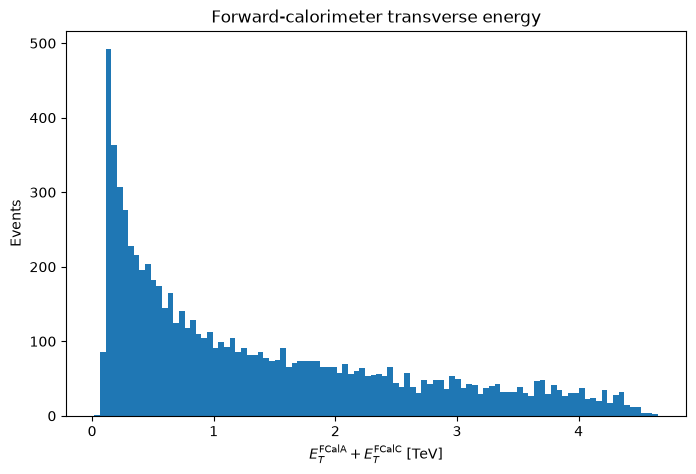

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(data_events.sumFCalEt, bins=100)
plt.xlabel(r"$E_T^{\mathrm{FCalA}} + E_T^{\mathrm{FCalC}}$ [TeV]")
plt.ylabel("Events")
plt.title("Forward-calorimeter transverse energy")
plt.show()


For the rest of the analysis, we will focus on four representative centrality intervals, ranging from very central to more peripheral collisions. These intervals will be used later when comparing the charged-particle spectra.

In [ ]:
def centrality_mask(events, low, high):
    """
    Select events whose stored centrality bin lies fully inside [low, high].

    This also works when a requested interval is composed of several
    narrower stored centrality bins.
    """
    return (
        (events.CentralityMin >= low)
        & (events.CentralityMax <= high)
    )


CENTRALITY_INTERVALS = {
    "0-5%": (0, 5),
    "20-30%": (20, 30),
    "40-50%": (40, 50),
    "60-80%": (60, 80),
}

for label, (low, high) in CENTRALITY_INTERVALS.items():
    mask = centrality_mask(data_events, low, high)
    print(f"{label:>6}: {int(ak.sum(mask)):,} events")


## Charged-particle spectra in centrality intervals
A charged-particle $p_T$ spectrum describes how the number of reconstructed charged particles is distributed as a function of transverse momentum. In heavy ion collisions, comparing these spectra across centrality classes lets us see how particle production changes with the collision geometry.

We now construct the charged-particle $p_T$ spectrum for each of the centrality intervals defined above. We use 0.25 GeV wide bins up to 5 GeV and 1 GeV wide bins from 5 to 10 GeV.

For each centrality class, the number of tracks in each $p_T$ bin is normalized by the number of selected events and by the bin width. This gives the per-event yield density that we will later use to compare central and peripheral collisions.


In [10]:
# Setup plot
PT_EDGES = np.concatenate(
    [
        np.linspace(0.0, 5.0, 21),
        np.arange(6.0, 11.0, 1.0),
    ]
)

PT_CENTERS = 0.5 * (PT_EDGES[:-1] + PT_EDGES[1:])
PT_WIDTHS = np.diff(PT_EDGES)

In [ ]:
def spectrum_for_centrality(tracks, events, low, high):
  """
  Calculate the per event track pT spectrum for a centrality interval.
  """
  event_mask = centrality_mask(events, low, high)
  selected_tracks = tracks[event_mask]

  track_mask = (selected_tracks.pt >= PT_EDGES[0]) & (selected_tracks.pt < PT_EDGES[-1])

  values = ak.to_numpy(ak.flatten(selected_tracks.pt[track_mask],axis=None))
  counts, _ = np.histogram(values, bins=PT_EDGES)

  n_events = int(ak.sum(event_mask))

  # Per event yield density
  yield_density = counts / max(n_events, 1) / PT_WIDTHS

  return {
      "counts": counts.astype(float),
      "n_events": n_events,
      "yield": yield_density,
  }


spectra = {
    label: spectrum_for_centrality(
        data_tracks,
        data_events,
        low,
        high
    )
    for label, (low, high) in CENTRALITY_INTERVALS.items()
}

for label, result in spectra.items():
    print(f"{label}: {result['n_events']:,} events, {int(result['counts'].sum()):,} tracks in 0–10 GeV")


The normalized spectra for the different centrality classes are shown below. A logarithmic $y$-axis is used because the charged-particle yield decreases rapidly with increasing $p_T$. Comparing the spectra already gives a indication of how the particle production changes between central and more peripheral collisions.

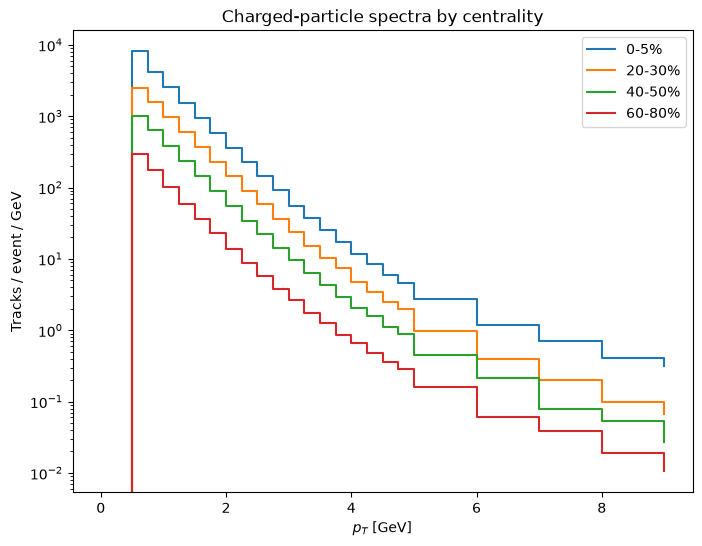

In [12]:
plt.figure(figsize=(8, 6))

for label, result in spectra.items():
    plt.step(
        PT_EDGES[:-1],
        result["yield"],
        where="post",
        label=label,
    )

plt.yscale("log")
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"Tracks / event / GeV")
plt.title("Charged-particle spectra by centrality")
plt.legend()
plt.show()


## Energy loss and the $R_{CP}$ observable
In heavy ion collisions, partons can lose energy while passing through the hot, dense medium. This modifies the observed charged-particle spectrum, particularly in central collisions where the produced medium is largest.

The central-to-peripheral ratio $R_{CP}$ compares the per-event charged-particle yield in a central collision interval, $C$, with that in a more peripheral reference interval, $P$:

$$ R_{CP}(p_T)= \frac{(1/N_{\mathrm{evt}}^C)\,dN^C/dp_T} {(1/N_{\mathrm{evt}}^P)\,dN^P/dp_T} \frac{\langle N_{\mathrm{coll}}^P\rangle} {\langle N_{\mathrm{coll}}^C\rangle}. $$

Here, $N_{\mathrm{evt}}$ is the number of selected events in a given centrality interval, while $dN/dp_T$ is the charged-particle spectrum measured in those events. The quantity $\langle N_{\mathrm{coll}}\rangle$ is the average number of individual nucleon–nucleon collisions that occur within a Pb–Pb collision for that centrality class.

More central Pb–Pb collisions involve a larger overlap between the two nuclei and therefore contain many more nucleon–nucleon collisions than peripheral events. The factor

$$ \frac{\langle N_{\mathrm{coll}}^P\rangle} {\langle N_{\mathrm{coll}}^C\rangle} $$

accounts for the different average number of binary nucleon–nucleon collisions in central and peripheral Pb–Pb events. Without this scaling, a larger yield in central events could arise simply because they contain more binary nucleon–nucleon collisions.

If particle production scaled only with the number of binary nucleon–nucleon collisions, $R_{CP}$ would be close to one. Values below one indicate a suppression of particle production in central collisions relative to the peripheral reference.

For more information about this observable and its interpretation, see the [ATLAS measurement of charged-particle spectra in Pb–Pb collisions](https://arxiv.org/abs/1504.04337), which presents $R_{CP}$. as a function of centrality and $p_T$.

### Obtain the collision normalization from MC
Unlike the charged-particle spectrum, $N_{\mathrm{coll}}$ cannot be measured directly in the detector. It is a property of the underlying collision geometry. In the heavy-ion MC sample, this information is stored for each simulated collision in `TruthEventsAuxDyn.NCOLL`.

We use the MC sample to determine $\langle N_{\mathrm{coll}}\rangle$ for each of the same centrality intervals used in data. These averages provide the collision normalization required in the $R_{CP}$ calculation.

The MC files are much larger than the data files used above, and remote access to the needed branches can be slow and unreliable for this exercise. We therefore download one MC file locally and process it in chunks. One file is sufficient for the tutorial, although more files could be used for better statistical precision.

In [ ]:
import subprocess

# Download one MC file and reuse it later
# This MC file is bigger than data, so we wont stream it
N_MC_FILES = 1
DOWNLOAD_DIR = Path("/content/hi_mc")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

urls_mc = atom.get_urls("420000", protocol="https", cache=False)
local_mc_files = []

for url in urls_mc[:N_MC_FILES]:
    destination = DOWNLOAD_DIR / url.rsplit("/", 1)[-1]

    if destination.exists():
        print(f"Using existing file: {destination}")
    else:
        print(f"Downloading: {destination.name}")
        subprocess.run(
            [
                "curl", "-L", "--fail", "--progress-bar",
                "-o", str(destination), url,
            ],
            check=True,
        )

    local_mc_files.append(str(destination))

The centrality interval and `NCOLL` are small event-level branches, so they can be read without loading the much larger truth-particle collection. For each centrality class, we calculate the average $N_{\mathrm{coll}}$ and the statistical uncertainty.

In [ ]:
NCOLL_BRANCHES = [
    "EventInfoAuxDyn.CentralityMin",
    "EventInfoAuxDyn.CentralityMax",
    "TruthEventsAuxDyn.NCOLL",
]

# Read only the event-level information needed for the geometry scaling
mc_geometry = uproot.concatenate(
    {filename: "CollectionTree" for filename in local_mc_files},
    expressions=NCOLL_BRANCHES,
    library="ak",
)

# TruthEvents contains one heavy-ion truth event per collision
ncoll_per_event = ak.firsts(
    mc_geometry["TruthEventsAuxDyn.NCOLL"]
)

NCOLL = {}

centrality_min = mc_geometry["EventInfoAuxDyn.CentralityMin"]
centrality_max = mc_geometry["EventInfoAuxDyn.CentralityMax"]

# Exclude special/non-standard centrality entries such as 80-0%
valid_centrality = centrality_min < centrality_max

for label, (low, high) in CENTRALITY_INTERVALS.items():

    # Obtain each interval
    mask = (
        valid_centrality
        & (centrality_min >= low)
        & (centrality_max <= high)
    )

    values = ak.to_numpy(ncoll_per_event[mask])
    values = values[np.isfinite(values)]

    mean = np.mean(values)
    error = np.std(values, ddof=1) / np.sqrt(len(values))

    NCOLL[label] = {
        "mean": mean,
        "error": error,
    }

    print(
        f"{label}: "
        f"<Ncoll> = {mean:.2f} +/- {error:.2f} "
        f"({len(values):,} MC events)"
    )

### Calculate $R_{CP}$

The data spectra are normalized using the MC-derived $\langle N_{\mathrm{coll}}\rangle$ values. The statistical uncertainty includes the Poisson uncertainty on the track counts and the finite MC uncertainty on the mean $N_{\mathrm{coll}}$.

This introductory calculation does not include uncertainties from the Glauber model, centrality calibration, detector response, or track selection.

In [15]:
PERIPHERAL = "60-80%"
rcp_results = {}

for label in ["0-5%", "20-30%", "40-50%"]:
    central = spectra[label]
    peripheral = spectra[PERIPHERAL]

    valid = (central["counts"] > 0) & (peripheral["counts"] > 0)
    values = np.full(len(PT_CENTERS), np.nan)
    errors = np.full(len(PT_CENTERS), np.nan)

    values[valid] = (
        central["yield"][valid]
        / peripheral["yield"][valid]
        * NCOLL[PERIPHERAL]["mean"]
        / NCOLL[label]["mean"]
    )

    relative_variance = (
        1.0 / central["counts"][valid]
        + 1.0 / peripheral["counts"][valid]
        + (NCOLL[label]["error"] / NCOLL[label]["mean"]) ** 2
        + (NCOLL[PERIPHERAL]["error"] / NCOLL[PERIPHERAL]["mean"]) ** 2
    )
    errors[valid] = values[valid] * np.sqrt(relative_variance)
    rcp_results[label] = (values, errors)

The $R_{CP}$ values below compare each centrality interval with the 60–80% interval, which is used as the peripheral reference $P$ in the definition above. For example, the 0–5% result compares the charged-particle yield in 0–5% events with that in 60–80% events, after accounting for their different average numbers of binary nucleon–nucleon collisions.

The horizontal line at $R_{CP}=1$ shows the expectation for particle production that scales with the number of binary collisions. The vertical bars show the statistical uncertainty described above.

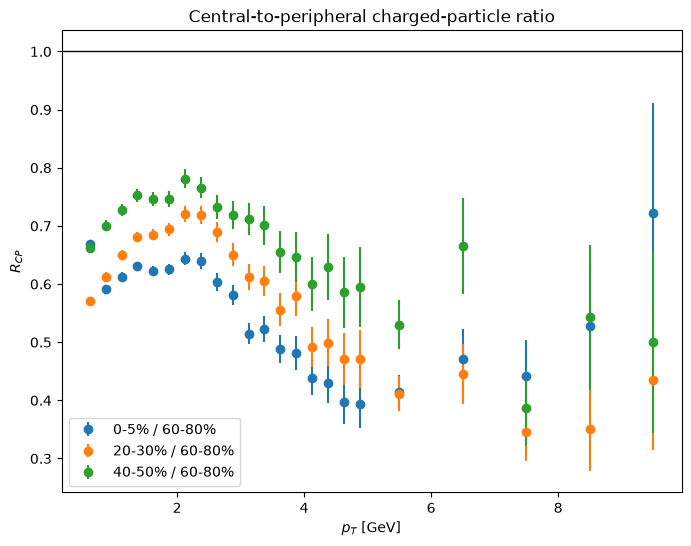

In [ ]:
plt.figure(figsize=(8, 6))

for label, (values, errors) in rcp_results.items():
    plt.errorbar(
        PT_CENTERS,
        values,
        yerr=errors,
        marker="o",
        linestyle="none",
        label=f"{label} / {PERIPHERAL}",
    )

plt.axhline(1.0, color="black", linewidth=1)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"$R_{CP}$")
plt.title("Central-to-peripheral charged-particle ratio")
plt.legend()
plt.show()

# Part II — tracking efficiency

Charged particles leave hits as they pass through the Inner Detector. Pattern-recognition and track-fitting algorithms combine these hits to reconstruct the particles' trajectories.

Not every charged particle is successfully reconstructed. The probability of reconstructing a particle can depend on its transverse momentum $p_T$, pseudorapidity $\eta$, and particle species. Measuring this **tracking efficiency** is important because detector inefficiencies affect observed charged-particle distributions.

The MC ntuple contains both truth particles and reconstructed tracks from the same events. We use them to measure the efficiency for pions, kaons, and protons.

## Selecting truth particles and reconstructed tracks

To measure the tracking efficiency, we first need to define the set of particles for which the efficiency will be evaluated. This is our fiducial region: we only consider truth particles within a chosen range of transverse momentum and pseudorapidity.

Truth particles are required to have
$$
0.4 < p_T < 10~\mathrm{GeV},
\qquad |\eta| < 2.5.
$$

The lower $p_T$ requirement avoids the very low-momentum region, where track reconstruction becomes increasingly difficult, while the $|\eta|<2.5$ requirement restricts the measurement to the tracking acceptance. The upper $p_T$ bound defines the range considered in this exercise.
Reconstructed tracks are selected in a very similar region,
$$
0.3 < p_T < 10~\mathrm{GeV},
\qquad |\eta| < 2.5.
$$

Because this is simulation, we can determine which reconstructed track originated from which truth particle. The ntuple stores this association using an ElementLink. Its m_persIndex component points to the corresponding particle in the event's TruthParticles collection.
We then define the tracking efficiency as
$$
\epsilon =
\frac{N(\text{selected truth particles linked to a selected track})}
{N(\text{selected truth particles})}.
$$

In other words, the denominator contains all truth particles in our chosen phase space, while the numerator contains those for which a reconstructed track was found. If more than one reconstructed track points to the same truth particle, that particle is counted only once.

The ntuple stores the association between a reconstructed track and its truth particle as an `ElementLink`. The `m_persIndex` component gives the position of the associated particle in the event's `TruthParticles` collection.

In [ ]:
# Index component of the track-to-truth ElementLink
TRUTH_LINK_INDEX = (
    "InDetTrackParticlesAuxDyn.truthParticleLink/"
    "InDetTrackParticlesAuxDyn.truthParticleLink.m_persIndex"
)

MC_BRANCHES = [
    "InDetTrackParticlesAuxDyn.theta",
    "InDetTrackParticlesAuxDyn.qOverP",
    TRUTH_LINK_INDEX,
    "TruthParticlesAuxDyn.pdgId",
    "TruthParticlesAuxDyn.px",
    "TruthParticlesAuxDyn.py",
    "TruthParticlesAuxDyn.pz",
]

SPECIES = {
    "pion": 211,
    "kaon": 321,
    "proton": 2212,
}

TRUTH_PT_MIN, TRUTH_PT_MAX = 0.4, 10.0
RECO_PT_MIN, RECO_PT_MAX = 0.3, 10.0
ETA_MAX = 2.5

EFF_PT_EDGES = np.geomspace(TRUTH_PT_MIN, TRUTH_PT_MAX, 21)
EFF_ETA_EDGES = np.linspace(-ETA_MAX, ETA_MAX, 26)

efficiency_counts = {
    name: {
        "pt_den": np.zeros(len(EFF_PT_EDGES) - 1, dtype=np.int64),
        "pt_num": np.zeros(len(EFF_PT_EDGES) - 1, dtype=np.int64),
        "eta_den": np.zeros(len(EFF_ETA_EDGES) - 1, dtype=np.int64),
        "eta_num": np.zeros(len(EFF_ETA_EDGES) - 1, dtype=np.int64),
    }
    for name in SPECIES
}

The large truth-particle collection is processed in chunks. Eligible truth particles form the denominator. Truth particles referenced by at least one selected reconstructed track form the numerator. Only the accumulated histogram counts are retained between chunks.

In [ ]:
processed_events = 0

for arrays in uproot.iterate(
    {filename: "CollectionTree" for filename in local_mc_files},
    expressions=MC_BRANCHES,
    step_size="50 MB",
    library="ak",
):
    # Reconstructed-track kinematics
    theta = arrays["InDetTrackParticlesAuxDyn.theta"]
    q_over_p = arrays["InDetTrackParticlesAuxDyn.qOverP"]
    reco_p = ak.where(q_over_p != 0, 1.0 / abs(q_over_p), np.nan)
    reco_pt = reco_p * abs(np.sin(theta)) / GeV
    reco_eta = -np.log(np.tan(theta / 2.0))
    reco_selected = (
        (reco_pt >= RECO_PT_MIN)
        & (reco_pt < RECO_PT_MAX)
        & (abs(reco_eta) < ETA_MAX)
    )

    # Truth-particle kinematics
    px = arrays["TruthParticlesAuxDyn.px"] / GeV
    py = arrays["TruthParticlesAuxDyn.py"] / GeV
    pz = arrays["TruthParticlesAuxDyn.pz"] / GeV
    truth_pt = np.sqrt(px**2 + py**2)
    truth_eta = ak.where(truth_pt > 0, np.arcsinh(pz / truth_pt), np.nan)
    truth_pdg = arrays["TruthParticlesAuxDyn.pdgId"]
    truth_selected = (
        (truth_pt >= TRUTH_PT_MIN)
        & (truth_pt < TRUTH_PT_MAX)
        & (abs(truth_eta) < ETA_MAX)
    )

    # Denominator: all eligible truth particles
    for name, pdg_id in SPECIES.items():
        mask = truth_selected & (abs(truth_pdg) == pdg_id)
        efficiency_counts[name]["pt_den"] += np.histogram(
            ak.to_numpy(ak.flatten(truth_pt[mask], axis=None)),
            bins=EFF_PT_EDGES,
        )[0]
        efficiency_counts[name]["eta_den"] += np.histogram(
            ak.to_numpy(ak.flatten(truth_eta[mask], axis=None)),
            bins=EFF_ETA_EDGES,
        )[0]

    # Numerator: truth particles linked from selected tracks
    truth_link_index = arrays[TRUTH_LINK_INDEX]

    for event in range(len(arrays)):
        links = ak.to_numpy(truth_link_index[event])
        links = np.unique(links[ak.to_numpy(reco_selected[event])].astype(np.int64))
        links = links[(links >= 0) & (links < len(truth_pdg[event]))]

        if len(links) == 0:
            continue

        event_pt = ak.to_numpy(truth_pt[event])
        event_eta = ak.to_numpy(truth_eta[event])
        event_pdg = ak.to_numpy(truth_pdg[event])
        event_selected = ak.to_numpy(truth_selected[event])

        for name, pdg_id in SPECIES.items():
            matched = links[
                event_selected[links]
                & (np.abs(event_pdg[links]) == pdg_id)
            ]
            efficiency_counts[name]["pt_num"] += np.histogram(
                event_pt[matched], bins=EFF_PT_EDGES
            )[0]
            efficiency_counts[name]["eta_num"] += np.histogram(
                event_eta[matched], bins=EFF_ETA_EDGES
            )[0]

    processed_events += len(arrays)

print(f"Processed {processed_events:,} MC events")

## Tracking efficiency as a function of $p_T$

The efficiency is calculated independently in each bin. The error bars show the binomial statistical uncertainty, $\sqrt{\epsilon(1-\epsilon)/N}$, where $N$ is the number of selected truth particles in the bin. A logarithmic $p_T$ axis makes the low-momentum region easier to inspect.

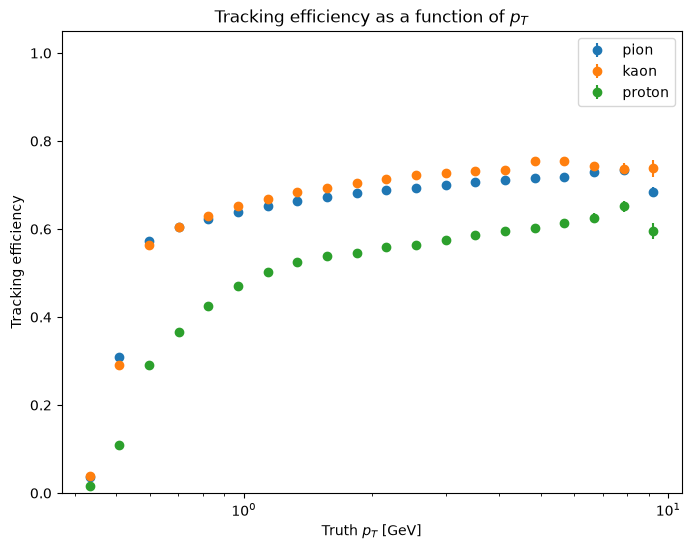

In [ ]:
plt.figure(figsize=(8, 6))

for name, counts in efficiency_counts.items():
    denominator = counts["pt_den"]
    efficiency = np.divide(
        counts["pt_num"], denominator,
        out=np.full_like(denominator, np.nan, dtype=float),
        where=denominator > 0,
    )
    variance = np.divide(
        efficiency * (1 - efficiency), denominator,
        out=np.full_like(efficiency, np.nan),
        where=denominator > 0,
    )
    uncertainty = np.sqrt(np.clip(variance, 0, None))
    centers = np.sqrt(EFF_PT_EDGES[:-1] * EFF_PT_EDGES[1:])

    plt.errorbar(
        centers, efficiency, yerr=uncertainty,
        marker="o", linestyle="none", label=name,
    )

plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel(r"Truth $p_T$ [GeV]")
plt.ylabel("Tracking efficiency")
plt.title(r"Tracking efficiency as a function of $p_T$")
plt.legend()
plt.show()

## Tracking efficiency as a function of $\eta$

The pseudorapidity dependence shows how tracking performance changes across the detector acceptance. The same particle selection and truth-link matching are used for all three species.

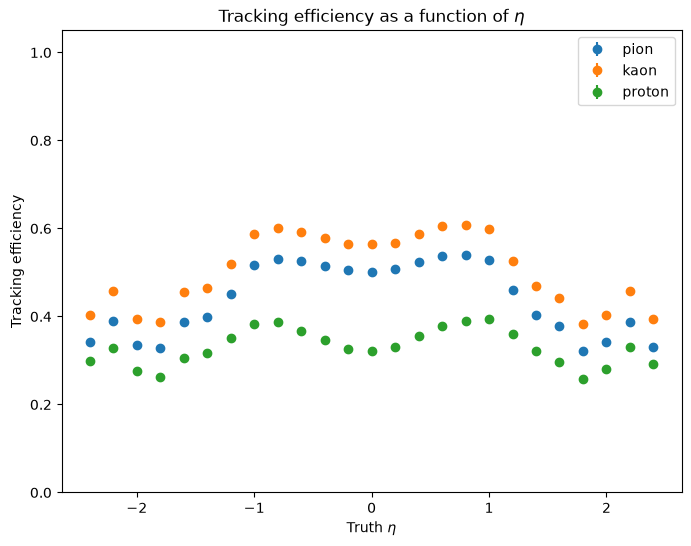

In [ ]:
plt.figure(figsize=(8, 6))

for name, counts in efficiency_counts.items():
    denominator = counts["eta_den"]
    efficiency = np.divide(
        counts["eta_num"], denominator,
        out=np.full_like(denominator, np.nan, dtype=float),
        where=denominator > 0,
    )
    variance = np.divide(
        efficiency * (1 - efficiency), denominator,
        out=np.full_like(efficiency, np.nan),
        where=denominator > 0,
    )
    uncertainty = np.sqrt(np.clip(variance, 0, None))
    centers = 0.5 * (EFF_ETA_EDGES[:-1] + EFF_ETA_EDGES[1:])

    plt.errorbar(
        centers, efficiency, yerr=uncertainty,
        marker="o", linestyle="none", label=name,
    )

plt.ylim(0, 1.05)
plt.xlabel(r"Truth $\eta$")
plt.ylabel("Tracking efficiency")
plt.title(r"Tracking efficiency as a function of $\eta$")
plt.legend()
plt.show()

## Summary

In this notebook, we have:

- studied forward-calorimeter activity and charged-particle spectra in data,
- obtained the $R_{CP}$ collision normalization from `NCOLL` in one MC sample,
- and measured truth-linked tracking efficiency for pions, kaons, and protons.

This is an introductory analysis using heavy ion data. It uses a limited number of files and statistical uncertainties only. A precision measurement would require validated event and track selections and a full treatment of detector, centrality, Glauber-model, and generator systematic uncertainties.

<div class="alert alert-block alert-info">
<b>We welcome your feedback!</b><br>
Please <a href="https://forms.gle/zKBqS1opAHHemv9U7">fill out this survey</a> to let us know what you thought of this notebook and our other materials. You can also enter a raffle to win some <a href="https://atlas-secretariat.web.cern.ch/merchandise">ATLAS merchandise</a>!
</div>